### Условие

Загружаем датасет из файла merged_data.csv - в нем уже есть вся необходимая информация и он очищен от нуллов и выбросов

**Задача 1.**
Изучаем различия между городами.

Рассчитайте по каждому городу:

+ Средний чек в месяц на пользователя
+ Долю индивидуальных тренировок от общего числа занятий
+ Количество уникальных пользователей

Постройте scatterplot, где:
+ Ось X — доля индивидуальных тренировок

+ Ось Y — средний чек

+ Цвет — город

Постройте пузырьковую диаграмму (bubble plot), где размер пузырька - это количество уникальных пользователей в городе

**Задача 2.** 
Изучаем ключевые метрики по возрастным группам

Разделите клиентов на три возрастные группы:

+ до 30 лет

+ от 30 до 45 лет

+ старше 45 лет

Для каждой возрастной группы рассчитайте:

+ Среднюю долю индивидуальных тренировок

+ Среднее количество тренировок в месяц

+ Средний месячный чек

+ Общее количество клиентов в группе

Представьте результаты в виде таблицы.
Сделайте выводы:

+ Как меняется поведение клиентов с возрастом?

+ Какие возрастные группы более склонны к индивидуальным тренировкам?

+ Есть ли возрастная группа с меньшей вовлечённостью, которую стоит дополнительно стимулировать?

**Задача 3.** 
Изучаем премиальный сегмент

+ Найдите 10 пользователей с самой высокой совокупной выручкой (LTR). Используйте сумму всех платежей пользователя за весь период.
+ Сохраните их id-шники в формате список
+ Выведите для этих пользователей город, пол, средний чек за месяц, среднее количество тренировок в месяц и количество месяцев, которые они тренировались.

**Задача 4.** 
Изучаем удержание пользователей после первого месяца тренировок:

Что нужно сделать:

+ Создать когорту для каждого пользователя — определить месяц их первого визита (min_mon).
+ Рассчитать индекс когорты (cohort_index), который показывает, какой по счёту месяц после первого визита рассматривается для каждого пользователя.
+ Для каждой когорты и каждого месяца жизни посчитать количество уникальных активных пользователей.
+ Построить когортную таблицу удержания — показать, какая доля пользователей осталась активной в каждом следующем месяце после первого визита.
+ Визуализировать результаты в виде тепловой карты с retention за первые 4 месяца для каждой когорты.

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# загружаем очищенный датасет
df = pd.read_csv('merged_data.csv')
df.head()

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,min_mon,max_mon,city,age,gender
0,1000,2023-03,0,2,0,3600,2,3600,2023-03,2023-12,СПб,44.0,female
1,1000,2023-04,0,4,0,7200,4,7200,2023-03,2023-12,СПб,44.0,female
2,1000,2023-05,0,4,0,6400,4,6400,2023-03,2023-12,СПб,44.0,female
3,1000,2023-06,0,2,0,3600,2,3600,2023-03,2023-12,СПб,44.0,female
4,1000,2023-07,0,4,0,7200,4,7200,2023-03,2023-12,СПб,44.0,female


### Задача 1. Различия по городам

In [3]:
pay_user = df.groupby(['id_user', 'city']).agg({'mon':'count',
                                                'cnt_indiv':'sum',
                                                'cnt_total':'sum',
                                                'sum_total':'sum'}).reset_index().rename(columns = {'mon':'nmonths'})
pay_user.head()

,id_user,city,nmonths,cnt_indiv,cnt_total,sum_total
0,1000,СПб,9,33,33,58600
1,1001,Москва,11,23,129,124800
2,1002,Москва,11,64,128,166000
3,1004,Екатеринбург,9,18,18,32000
4,1005,СПб,2,7,7,12600


In [4]:
pay_user['avg_check_per_mon'] = pay_user['sum_total'] / pay_user['nmonths']
pay_user['share_indiv_trains'] = pay_user['cnt_indiv'] / pay_user['cnt_total']
pay_user.head().round(2)

,id_user,city,nmonths,cnt_indiv,cnt_total,sum_total,avg_check_per_mon,share_indiv_trains
0,1000,СПб,9,33,33,58600,6511.11,1.00
1,1001,Москва,11,23,129,124800,11345.45,0.18
2,1002,Москва,11,64,128,166000,15090.91,0.50
3,1004,Екатеринбург,9,18,18,32000,3555.56,1.00
4,1005,СПб,2,7,7,12600,6300.00,1.00


In [5]:
city_stats = pay_user.groupby('city').agg({'id_user':'nunique',
                                          'avg_check_per_mon':'mean',
                                          'share_indiv_trains':'mean'}).reset_index().rename(columns = {'id_user':'nusers'})
city_stats.round(2)

,city,nusers,avg_check_per_mon,share_indiv_trains
0,Екатеринбург,128,6735.82,0.31
1,Казань,127,6698.70,0.25
2,Москва,310,7194.96,0.65
3,СПб,273,7123.47,0.33


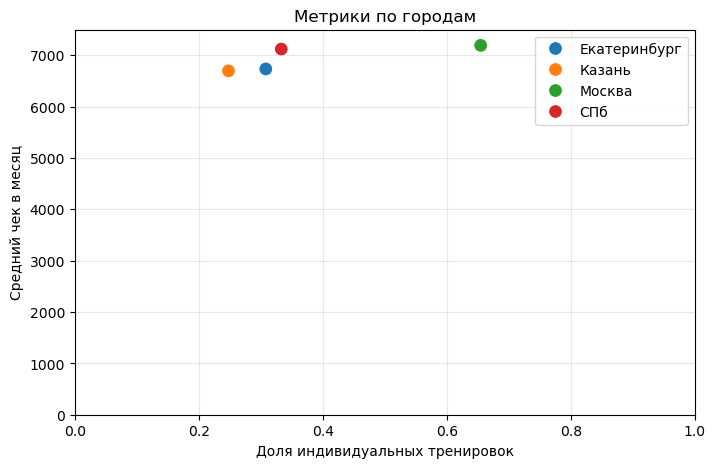

In [6]:
# динамика тренировок
plt.figure(figsize = (8, 5))
plt.xlim(0, 1)
plt.ylim(0, 7500)
sns.scatterplot(data = city_stats,
               x = 'share_indiv_trains',
               y = 'avg_check_per_mon',
               hue = 'city',
               s = 100)
plt.xlabel('Доля индивидуальных тренировок')
plt.ylabel('Средний чек в месяц')
plt.title('Метрики по городам')
plt.legend()
plt.grid(True, alpha = 0.3)
plt.show()

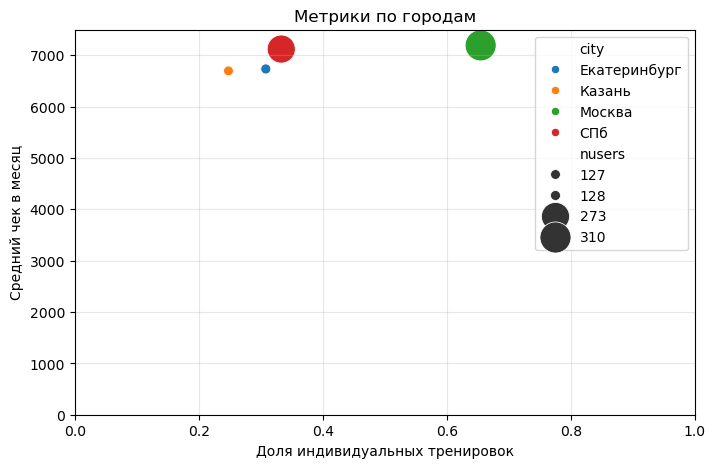

In [7]:
# динамика тренировок
plt.figure(figsize = (8, 5))
plt.xlim(0, 1)
plt.ylim(0, 7500)
sns.scatterplot(data = city_stats,
                x = 'share_indiv_trains',
                y = 'avg_check_per_mon',
                hue = 'city',
                size = 'nusers',
                sizes = (50, 500))
plt.xlabel('Доля индивидуальных тренировок')
plt.ylabel('Средний чек в месяц')
plt.title('Метрики по городам')
plt.legend()
plt.grid(True, alpha = 0.3)
plt.savefig('Метрики по городам.png', dpi = 300, bbox_inches = 'tight', transparent = True)
plt.show()

### Задача 2. сравнение по возрастным когортам

In [8]:
def age_group(age):
    if age <=30:
        return '18 - 30'
    elif (age >= 31) and (age <= 45):
        return '31 - 45'
    else:
        return '46+'

In [9]:
df['age_gr'] = df['age'].apply(age_group)
df.head()

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,min_mon,max_mon,city,age,gender,age_gr
0,1000,2023-03,0,2,0,3600,2,3600,2023-03,2023-12,СПб,44.0,female,31 - 45
1,1000,2023-04,0,4,0,7200,4,7200,2023-03,2023-12,СПб,44.0,female,31 - 45
2,1000,2023-05,0,4,0,6400,4,6400,2023-03,2023-12,СПб,44.0,female,31 - 45
3,1000,2023-06,0,2,0,3600,2,3600,2023-03,2023-12,СПб,44.0,female,31 - 45
4,1000,2023-07,0,4,0,7200,4,7200,2023-03,2023-12,СПб,44.0,female,31 - 45


In [10]:
age_user = df.groupby(['id_user', 'age_gr']).agg({'mon':'count',
                                               'cnt_indiv':'sum',
                                               'cnt_total':'sum',
                                               'sum_total':'sum'}).reset_index().rename(columns = {'mon':'nmonths'})
age_user.head()

,id_user,age_gr,nmonths,cnt_indiv,cnt_total,sum_total
0,1000,31 - 45,9,33,33,58600
1,1001,31 - 45,11,23,129,124800
2,1002,31 - 45,11,64,128,166000
3,1004,46+,9,18,18,32000
4,1005,31 - 45,2,7,7,12600


In [11]:
age_user['avg_check_per_mon'] = age_user['sum_total'] / age_user['nmonths']

In [12]:
age_user['share_indiv'] = age_user['cnt_indiv'] / age_user['cnt_total']

In [13]:
age_user['avg_train_per_mon'] = age_user['cnt_total'] / age_user['nmonths']

In [14]:
age_user.head()

,id_user,age_gr,nmonths,cnt_indiv,cnt_total,sum_total,avg_check_per_mon,share_indiv,avg_train_per_mon
0,1000,31 - 45,9,33,33,58600,6511.111111,1.000000,3.666667
1,1001,31 - 45,11,23,129,124800,11345.454545,0.178295,11.727273
2,1002,31 - 45,11,64,128,166000,15090.909091,0.500000,11.636364
3,1004,46+,9,18,18,32000,3555.555556,1.000000,2.000000
4,1005,31 - 45,2,7,7,12600,6300.000000,1.000000,3.500000


In [15]:
age_segm = age_user.groupby('age_gr').agg({'id_user':'nunique',
                                          'nmonths':'mean',
                                          'avg_check_per_mon':'mean',
                                          'avg_train_per_mon':'mean',
                                          'share_indiv':'mean'}).reset_index().rename(columns = {'id_user': 'nusers'})

age_segm

,age_gr,nusers,nmonths,avg_check_per_mon,avg_train_per_mon,share_indiv
0,18 - 30,278,5.399281,8222.747802,7.290366,0.446690
1,31 - 45,271,5.343173,7774.985357,7.003930,0.445543
2,46+,289,5.681661,5173.422485,4.737098,0.414714


### Задача 3. Топ-10 пользователей по LTR

In [16]:
df_gr = df.groupby('id_user').agg({'sum_total':'sum'}).reset_index().sort_values('sum_total', ascending = False).head(10)
df_gr

,id_user,sum_total
2,1002,166000
551,1657,164200
319,1381,147600
135,1153,147400
420,1506,146400
27,1029,140000
12,1013,139800
485,1582,136200
446,1536,134400
402,1482,131400


In [17]:
user_lst = df_gr['id_user'].tolist()
user_lst

[1002, 1657, 1381, 1153, 1506, 1029, 1013, 1582, 1536, 1482]

In [18]:
df_top = df[df['id_user'].isin(user_lst)]
df_top.head()

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,min_mon,max_mon,city,age,gender,age_gr
20,1002,2023-02,4,8,3200,14400,12,17600,2023-02,2023-12,Москва,34.0,male,31 - 45
21,1002,2023-03,4,8,3200,14400,12,17600,2023-02,2023-12,Москва,34.0,male,31 - 45
22,1002,2023-04,7,4,5600,7200,11,12800,2023-02,2023-12,Москва,34.0,male,31 - 45
23,1002,2023-05,2,10,1600,16000,12,17600,2023-02,2023-12,Москва,34.0,male,31 - 45
24,1002,2023-06,7,4,5600,7200,11,12800,2023-02,2023-12,Москва,34.0,male,31 - 45


In [19]:
user_top = df_top.groupby(['id_user', 'city', 'gender', 'age_gr']).agg({'mon':'count',
                                                                       'cnt_total':'sum',
                                                                       'sum_total':'sum'}).reset_index().rename(columns = {'mon':'nmonths'})

user_top

,id_user,city,gender,age_gr,nmonths,cnt_total,sum_total
0,1002,Москва,male,31 - 45,11,128,166000
1,1013,Москва,male,31 - 45,11,151,139800
2,1029,СПб,female,31 - 45,8,126,140000
3,1153,СПб,male,46+,12,118,147400
4,1381,Москва,female,18 - 30,12,159,147600
5,1482,Москва,female,18 - 30,11,110,131400
6,1506,Москва,female,18 - 30,10,138,146400
7,1536,Москва,female,18 - 30,9,125,134400
8,1582,Екатеринбург,male,31 - 45,8,127,136200
9,1657,СПб,male,18 - 30,10,144,164200


In [20]:
user_top['avg_check_per_mon'] = user_top['sum_total'] / user_top['nmonths']

In [21]:
user_top['avg_train_per_mon'] = user_top['cnt_total'] / user_top['nmonths']

In [22]:
user_top

,id_user,city,gender,age_gr,nmonths,cnt_total,sum_total,avg_check_per_mon,avg_train_per_mon
0,1002,Москва,male,31 - 45,11,128,166000,15090.909091,11.636364
1,1013,Москва,male,31 - 45,11,151,139800,12709.090909,13.727273
2,1029,СПб,female,31 - 45,8,126,140000,17500.000000,15.750000
3,1153,СПб,male,46+,12,118,147400,12283.333333,9.833333
4,1381,Москва,female,18 - 30,12,159,147600,12300.000000,13.250000
5,1482,Москва,female,18 - 30,11,110,131400,11945.454545,10.000000
6,1506,Москва,female,18 - 30,10,138,146400,14640.000000,13.800000
7,1536,Москва,female,18 - 30,9,125,134400,14933.333333,13.888889
8,1582,Екатеринбург,male,31 - 45,8,127,136200,17025.000000,15.875000
9,1657,СПб,male,18 - 30,10,144,164200,16420.000000,14.400000


In [23]:
user_top['city'].value_counts()

city
Москва          6
СПб             3
Екатеринбург    1
Name: count, dtype: int64

In [24]:
user_top['gender'].value_counts()

gender
male      5
female    5
Name: count, dtype: int64

In [25]:
user_top['age_gr'].value_counts()

age_gr
18 - 30    5
31 - 45    4
46+        1
Name: count, dtype: int64

### Задача 4. Анализ доходимости когорт

In [26]:
df['mon'] = pd.to_datetime(df['mon'], format = "%Y-%m")

In [27]:
df['min_mon'] = pd.to_datetime(df['min_mon'], format = "%Y-%m")

In [28]:
df.head()

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,min_mon,max_mon,city,age,gender,age_gr
0,1000,2023-03-01,0,2,0,3600,2,3600,2023-03-01,2023-12,СПб,44.0,female,31 - 45
1,1000,2023-04-01,0,4,0,7200,4,7200,2023-03-01,2023-12,СПб,44.0,female,31 - 45
2,1000,2023-05-01,0,4,0,6400,4,6400,2023-03-01,2023-12,СПб,44.0,female,31 - 45
3,1000,2023-06-01,0,2,0,3600,2,3600,2023-03-01,2023-12,СПб,44.0,female,31 - 45
4,1000,2023-07-01,0,4,0,7200,4,7200,2023-03-01,2023-12,СПб,44.0,female,31 - 45


In [29]:
df['cohort_index'] = df['mon'].dt.month - df['min_mon'].dt.month 
df.head()

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,min_mon,max_mon,city,age,gender,age_gr,cohort_index
0,1000,2023-03-01,0,2,0,3600,2,3600,2023-03-01,2023-12,СПб,44.0,female,31 - 45,0
1,1000,2023-04-01,0,4,0,7200,4,7200,2023-03-01,2023-12,СПб,44.0,female,31 - 45,1
2,1000,2023-05-01,0,4,0,6400,4,6400,2023-03-01,2023-12,СПб,44.0,female,31 - 45,2
3,1000,2023-06-01,0,2,0,3600,2,3600,2023-03-01,2023-12,СПб,44.0,female,31 - 45,3
4,1000,2023-07-01,0,4,0,7200,4,7200,2023-03-01,2023-12,СПб,44.0,female,31 - 45,4


In [30]:
cohort_stats = df.groupby(['min_mon','cohort_index']).agg(active_users = ('id_user', 'nunique')).reset_index()
cohort_stats.head()

,min_mon,cohort_index,active_users
0,2023-01-01,0,337
1,2023-01-01,1,262
2,2023-01-01,2,205
3,2023-01-01,3,168
4,2023-01-01,4,159


In [31]:
cohort_size = cohort_stats[cohort_stats['cohort_index'] == 0][['min_mon', 'active_users']].rename(columns =\
                                                                                                         {'active_users':'cohsize'})

In [32]:
cohort_data = cohort_stats.merge(cohort_size, on = 'min_mon')
cohort_data.head()

,min_mon,cohort_index,active_users,cohsize
0,2023-01-01,0,337,337
1,2023-01-01,1,262,337
2,2023-01-01,2,205,337
3,2023-01-01,3,168,337
4,2023-01-01,4,159,337


In [33]:
cohort_data['retention'] = cohort_data['active_users'] / cohort_data['cohsize']
cohort_data.head().round(2)

,min_mon,cohort_index,active_users,cohsize,retention
0,2023-01-01,0,337,337,1.00
1,2023-01-01,1,262,337,0.78
2,2023-01-01,2,205,337,0.61
3,2023-01-01,3,168,337,0.50
4,2023-01-01,4,159,337,0.47


In [34]:
retention_table = pd.pivot_table(cohort_data, index = 'min_mon', columns = 'cohort_index', values = 'retention')

In [35]:
retention_table.index = retention_table.index.strftime('%Y-%m')

In [36]:
retention_table.iloc[:, :4]

cohort_index,0,1,2,3
min_mon,,,,
2023-01,1.0,0.777448,0.608309,0.498516
2023-02,1.0,0.761364,0.602273,0.568182
2023-03,1.0,0.746988,0.590361,0.578313
2023-04,1.0,0.725806,0.645161,0.548387
2023-05,1.0,0.701754,0.561404,0.614035
2023-06,1.0,0.823529,0.705882,0.549020
2023-07,1.0,0.770833,0.666667,0.666667
2023-08,1.0,0.885714,0.571429,0.400000
2023-09,1.0,0.678571,0.500000,0.464286


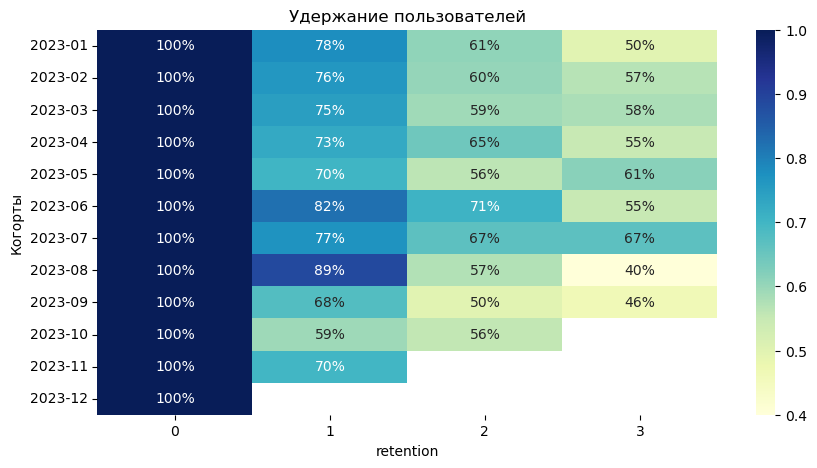

In [37]:
plt.figure(figsize = (10, 5))
sns.heatmap(retention_table.iloc[:, :4], annot = True, fmt = ".0%", cmap = 'YlGnBu')
plt.xlabel('retention')
plt.ylabel('Когорты')
plt.title('Удержание пользователей')
plt.savefig('Удержание пользователей.png', dpi = 300, bbox_inches = 'tight', transparent = True)
plt.show()